In [49]:
import torch
import matplotlib.pyplot as plt

# **Proceso Poisson**

In [99]:
class PoissonProcess1:

    def __init__(self, lam):

        self.lam = lam 
        self.expo = torch.distributions.Exponential(self.lam) 

    def simulate(self, t):

        time = 0
        S = []
        
        while True:

            T = self.expo.sample().item()
            time += T 

            if time > t:
                break
            S.append(time)

        S = torch.tensor(S)
        n = len(S)
        
        return S, n

    def plot(self, t, color = "blue", linestyle = "-",marker = None):
       
        S, n = self.simulate(t)

        # tiempos para escalón (incluimos 0 y t final)
        times = torch.cat((torch.tensor([0.0]), S, torch.tensor([t])))
        
        # valores del conteo
        counts = torch.arange(0, n + 1)
        counts = torch.cat((counts, torch.tensor([n])))

        plt.figure()
        plt.step(times, counts, where="post", color=color, linestyle=linestyle, marker=marker)
        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.title(f"Proceso de Poisson (λ={self.lam})")
        plt.show()
            

            
            
            

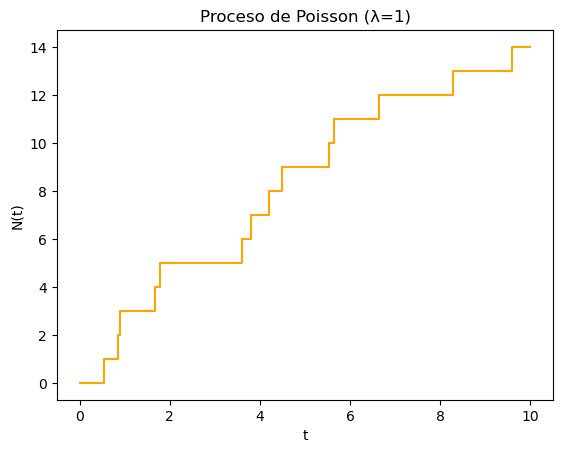

In [101]:
poi_p = PoissonProcess1(1)
poi_p.plot(10,color='orange',linestyle="-")


In [70]:
class PoissonProcess2:

    def __init__(self, lam):
        self.lam = lam
        
    def simulate(self, t, n):
        """
        Simula el proceso de Poisson en una malla uniforme.

        Parameters
        ----------
        t : float
            Tiempo final
        n : int
            Número de intervalos

        Returns
        -------
        times : tensor
            Malla de tiempos
        N : tensor
            Valores del proceso
        """

        # malla uniforme
        times = torch.linspace(0, t, n + 1)

        N = torch.zeros(n + 1)

        delta = t / n  # longitud de cada intervalo
        for i in range(1, n + 1):

            X = torch.distributions.Poisson(self.lam * delta).sample()
            N[i] = N[i - 1] + X

        return times, N

    def plot(self, t, n, color="blue", linestyle="-", marker=None):
        """
        Grafica la trayectoria.
        """

        times, N = self.simulate(t, n)

        plt.figure()
        plt.step(
            times,
            N,
            where="post",
            color=color,
            linestyle=linestyle,
            marker=marker,
        )

        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.title(f"Proceso de Poisson (λ={self.lam})")
        plt.show()

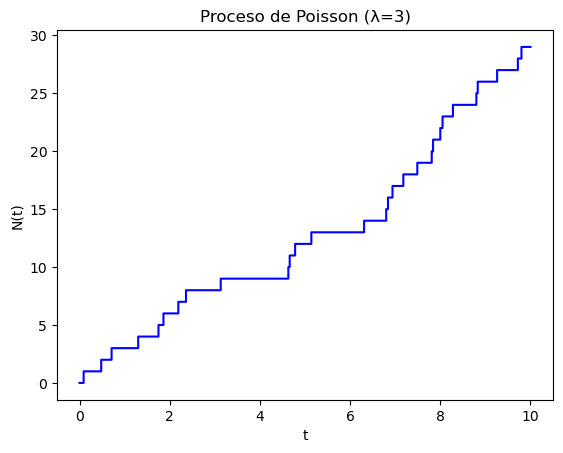

In [97]:
poi_p2 = PoissonProcess2(3)
poi_p2.plot(10,1000)

In [119]:

class PoissonProcess3:

    def __init__(self, lam):
        self.lam = lam

    def simulate(self, tf):
        """
        Simula el proceso de Poisson en [0, tf]
        usando el método de ordenamiento de uniformes.
        """

        # Paso 1: número de saltos
        N = int(torch.distributions.Poisson(self.lam * tf).sample().item())

        # Paso 2: tiempos sin ordenar
        U = torch.rand(N) * tf

        # Paso 3: ordenar tiempos
        S = torch.sort(U).values

        return S, N

    def plot(self, tf, color="blue", linestyle="-", marker=None):
        """
        Grafica una trayectoria del proceso.
        """

        S, N = self.simulate(tf)

        # construir escalón
        times = torch.cat((torch.tensor([0.0]), S, torch.tensor([tf])))
        counts = torch.arange(0, N + 1)
        counts = torch.cat((counts, torch.tensor([N])))

        plt.figure()
        plt.step(
            times,
            counts,
            where="post",
            color=color,
            linestyle=linestyle,
            marker=marker,
        )

        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.title(f"Proceso de Poisson (λ={self.lam})")
        plt.show()


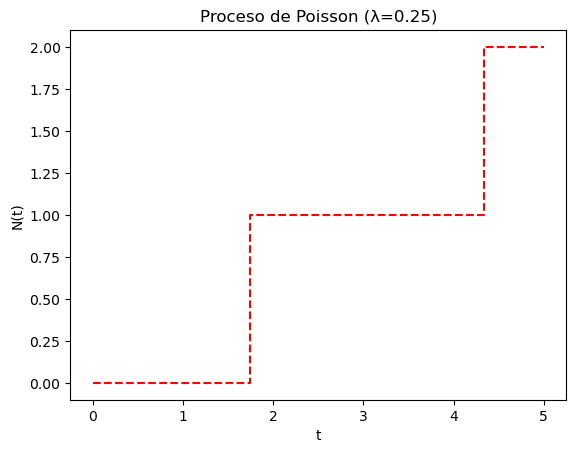

In [126]:
pp = PoissonProcess3(lam=1/4)
pp.plot(tf=5.0, color="red", linestyle="--")

In [128]:
class CustomDist(torch.distributions.Distribution):

    def sample(self, sample_shape=torch.Size()):
        U = torch.rand(sample_shape)
        return torch.exp(U)

In [129]:
cd = CustomDist()

C:\Users\Academica\anaconda3\Lib\site-packages\torch\distributions\distribution.py:55: UserWarning: <class '__main__.CustomDist'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


(array([0.93640914, 0.81419234, 0.68964875, 0.62039288, 0.56103071,
        0.52203791, 0.46616699, 0.42251898, 0.40505952, 0.38236222]),
 array([1.00000131, 1.17182791, 1.34365463, 1.51548123, 1.68730783,
        1.85913444, 2.03096104, 2.20278788, 2.37461448, 2.54644108,
        2.71826768]),
 <BarContainer object of 10 artists>)

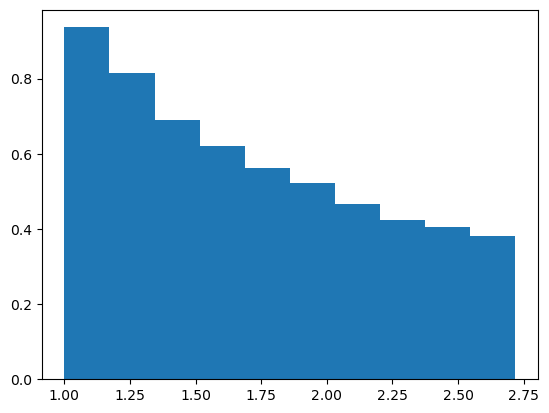

In [138]:
x = cd.sample(torch.Size([10000]))
plt.hist(x,density=True)

In [135]:
cd.sample(torch.Size([100000]))

tensor([1.2217, 1.2744, 1.9076,  ..., 1.1254, 1.4143, 1.5948])

In [139]:
torch.trapz?

Docstring:
trapz(y, x, *, dim=-1) -> Tensor

Alias for :func:`torch.trapezoid`.
Type:      builtin_function_or_method